In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## I - Modèle de taux

1) Simulation d'un modèle de taux 

Pour se familiariser avec l'implémentation des calculs pour la simulation des processus stochastiques.
On ne considère pas le terme déterministe dans un premier temps (considéré nul)

In [161]:
# Paramètres du modèle G2++
r0 = 0.03  # taux court initial
T = 10  # horizon de simulation en années
N = 1000  # nombre de pas de temps
dt = T / N  # discrétisation du temps
t_grid = np.linspace(0, T, N + 1)

# Paramètres du modèle (à ajuster)
a, b = 0.1, 0.3  # coefficients de régression vers la moyenne
sigma, eta = 0.02, 0.01  # volatilités
rho = 0.5  # corrélation entre W1 et W2

# Observé
f_0_T = 0.03  # taux court initial

In [162]:
# Génération des mouvements browniens corrélés W1 et W2
dW1 = np.random.normal(0, np.sqrt(dt), N)
dW2 = rho * dW1 + np.sqrt(1 - rho**2) * np.random.normal(0, np.sqrt(dt), N)

W1 = np.concatenate(([0], np.cumsum(dW1)))
W2 = np.concatenate(([0], np.cumsum(dW2)))



- Solution analytique des processus

Les processus $x(t)$ et $y(t)$ du modèle G2++ suivent les équations différentielles stochastiques :

$$
dx(t) = -a x(t) dt + \sigma dW_1(t)
$$

$$
dy(t) = -b y(t) dt + \eta dW_2(t)
$$

où $W_{1}(t)$ et $W_{2}(t)$ sont des mouvements browniens corrélés avec un coefficient $\rho$.

### **Solution intégrée des EDS**

En intégrant ces équations, on obtient les solutions analytiques :

$$
x(t) = x(0) e^{-a t} + \sigma \int_0^t e^{-a (t-s)} dW_1(s)
$$

$$
y(t) = y(0) e^{-b t} + \eta \int_0^t e^{-b (t-s)} dW_2(s)
$$

Après discrétisation sur un pas de temps $\Delta t$, nous utilisons :

$$
x_{i+1} = x_i e^{-a \Delta t} + \sigma \sqrt{\frac{1 - e^{-2a \Delta t}}{2a}} Z_1
$$

$$
y_{i+1} = y_i e^{-b \Delta t} + \eta \sqrt{\frac{1 - e^{-2b \Delta t}}{2b}} Z_2
$$

où $ Z_1 \sim \mathcal{N}(0,1) $ et $ Z_2 \sim \mathcal{N}(0,1) $ sont des variables normales centrées réduites, générées de manière corrélée :

$$
Z_2 = \rho Z_1 + \sqrt{1 - \rho^2} \cdot \mathcal{N}(0,1)
$$


In [163]:
# Simulation des processus x(t) et y(t)
x = np.zeros(N + 1)
y = np.zeros(N + 1)

for t in range(1, N + 1):
    x[t] = x[t-1] * np.exp(-a) + W1[t-1] * sigma * np.sqrt((1 - np.exp(-2*a))/(2*a))
    y[t] = y[t-1]* np.exp(-b) + W2[t-1] * eta * np.sqrt((1 - np.exp(-2*b))/(2*b))



In [164]:
# Simulation de theta(t) (simplifiée sans courbe de taux initiale)
theta = np.zeros(N + 1)  # Pour l'instant, on prend une approximation à zéro

# Calcul du taux r(t)
r = x + y + theta



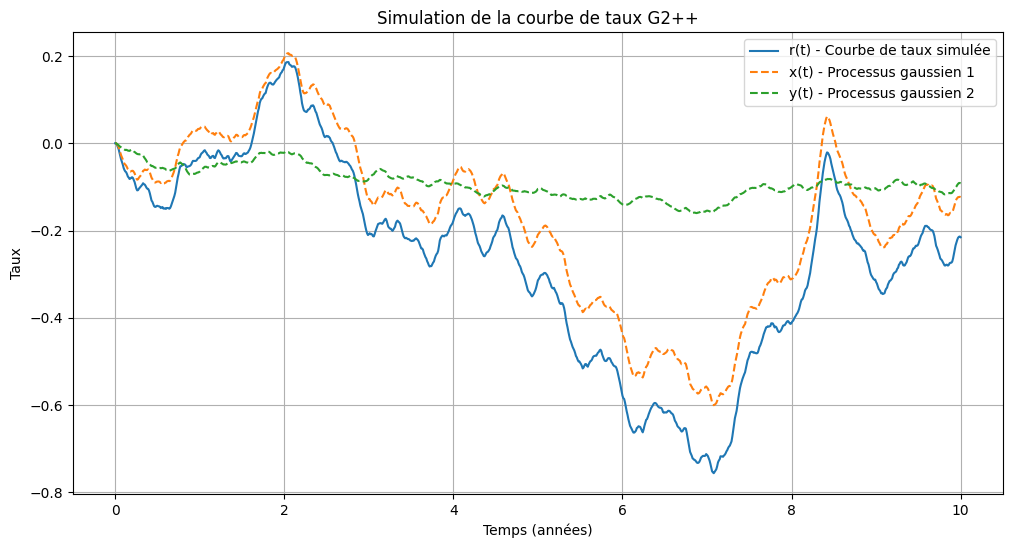

In [165]:
# Affichage des courbes
plt.figure(figsize=(12, 6))
plt.plot(t_grid, r, label='r(t) - Courbe de taux simulée')
plt.plot(t_grid, x, label='x(t) - Processus gaussien 1', linestyle='dashed')
plt.plot(t_grid, y, label='y(t) - Processus gaussien 2', linestyle='dashed')
plt.xlabel('Temps (années)')
plt.ylabel('Taux')
plt.legend()
plt.title('Simulation de la courbe de taux G2++')
plt.grid()
plt.show()

# Stockage des résultats dans un DataFrame
df_rates = pd.DataFrame({'Temps': t_grid, 'r(t)': r, 'x(t)': x, 'y(t)': y})


2) Ajout du terme déterministe

In [123]:
data = pd.ExcelFile("Input_GSE.xlsx")
data.sheet_names

['Cap Volatility', 'EIOPA Rate', 'EURIBOR Rate', 'Call Euro Stoxx 50']

In [124]:
# Read the data from the specified sheet
courbe_taux = pd.read_excel(data, sheet_name="EIOPA Rate", header=0)

courbe_taux = courbe_taux.iloc[:, :2]
courbe_taux = courbe_taux.dropna()

courbe_taux.head()

,Maturity,Rate
0,1,0.02236
1,2,0.02093
2,3,0.02093
3,4,0.02120
4,5,0.02142


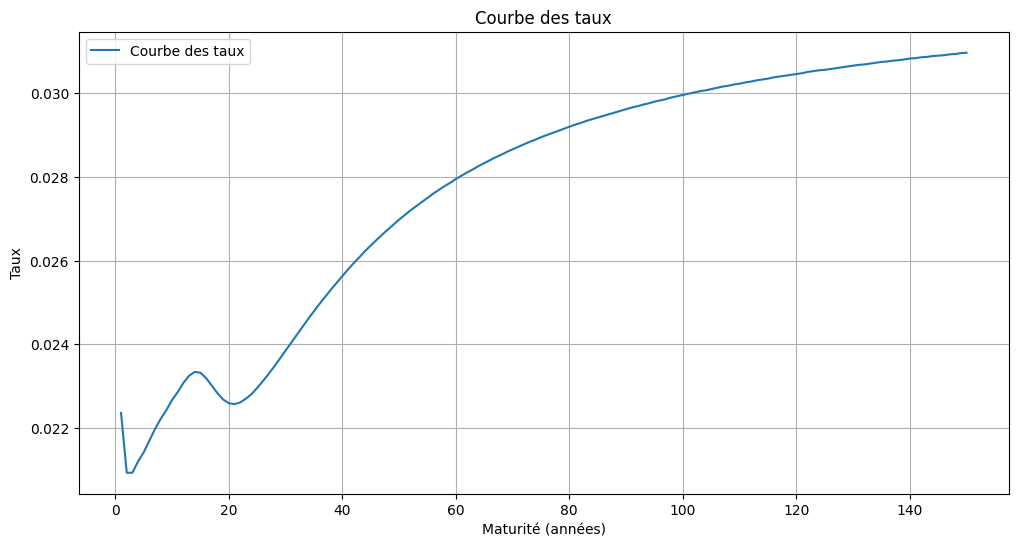

In [125]:
# Plot the yield curve
plt.figure(figsize=(12, 6))
plt.plot(courbe_taux['Maturity'], courbe_taux['Rate'], label='Courbe des taux')
plt.xlabel('Maturité (années)')
plt.ylabel('Taux')
plt.legend()
plt.title('Courbe des taux')
plt.grid()
plt.show()

On a besoin pour coller à la courbe des taux de calculer les taux forward f(0,t)

In [126]:
maturities = courbe_taux["Maturity"].values
zero_coupon_rates = courbe_taux["Rate"].values

Methode NSS pour calculer le taux forward :  
$$
f(0,t) = \beta_0 + \beta_1 \cdot \alpha_1(t) + \beta_2 \cdot \alpha_2(t) + \beta_3 \cdot \alpha_3(t)
$$

avec :

$$
\alpha_1(t) = \frac{1 - e^{-t/\tau_1}}{t/\tau_1}
$$

$$
\alpha_2(t) = \alpha_1(t) - e^{-t/\tau_1}
$$

$$
\alpha_3(t) = \frac{1 - e^{-t/\tau_2}}{t/\tau_2} - e^{-t/\tau_2}
$$


In [52]:
from scipy.optimize import minimize

# Fonction qui calcule le taux forward f(0,t) selon le modèle NSS
def forward_0t(t, params):
    """
    Modèle de Nelson-Siegel-Svensson pour la courbe de taux forward instantanée.
    
    Arguments:
    t : float ou np.array : maturité en années
    params : list ou np.array : paramètres [beta0, beta1, beta2, beta3, tau1, tau2]
    
    Retourne:
    f(0,t) : taux forward instantané
    """
    beta0, beta1, beta2, beta3, tau1, tau2 = params

    alpha1 = (1 - np.exp(-t / tau1)) / (t / tau1)
    alpha2 = alpha1 - np.exp(-t / tau1)
    alpha3 = (1 - np.exp(-t / tau2)) / (t / tau2) - np.exp(-t / tau2)

    return beta0 + beta1 * alpha1 + beta2 * alpha2 + beta3 * alpha3

Minimisation par somme des écarts au carré

In [53]:
# Fonction d'objectif à minimiser pour calibrer les paramètres NSS
def NSS_objectif(params, maturities, rates):
    """
    Fonction d'erreur quadratique pour l'optimisation NSS.
    """
    return np.sum((forward_0t(maturities, params) - rates) ** 2)

In [98]:
# Estimation des paramètres initiaux (valeurs de départ pour l'optimisation)
initial_params = [0.03, -0.02, 0.02, -0.01, 2.0, 10.0]

# Exécution de l'optimisation
res = minimize(NSS_objectif, x0=initial_params, args=(maturities, zero_coupon_rates), method="Nelder-Mead")

# Récupération des paramètres optimisés
params_NSS = res.x

# Calcul de la courbe des taux forward calibrée avec les paramètres NSS optimisés
taux_forward_NSS = forward_0t(maturities, params_NSS)

C:\Users\massi\AppData\Local\Temp\ipykernel_27724\1566387235.py:17: RuntimeWarning: overflow encountered in exp
  alpha1 = (1 - np.exp(-t / tau1)) / (t / tau1)
C:\Users\massi\AppData\Local\Temp\ipykernel_27724\1566387235.py:18: RuntimeWarning: overflow encountered in exp
  alpha2 = alpha1 - np.exp(-t / tau1)
C:\Users\massi\AppData\Local\Temp\ipykernel_27724\1566387235.py:18: RuntimeWarning: invalid value encountered in subtract
  alpha2 = alpha1 - np.exp(-t / tau1)
C:\Users\massi\AppData\Local\Temp\ipykernel_27724\1984364784.py:6: RuntimeWarning: overflow encountered in square
  return np.sum((forward_0t(maturities, params) - rates) ** 2)


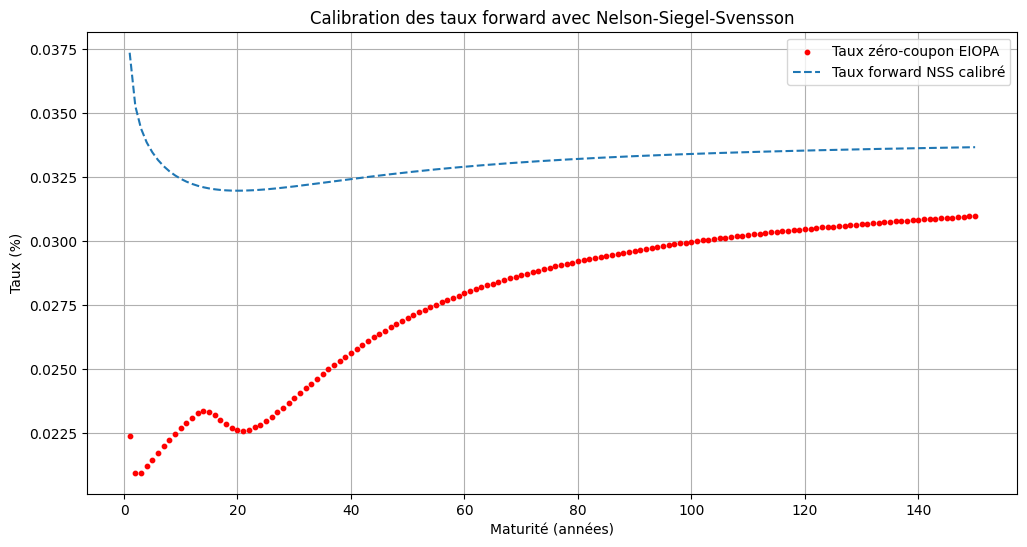

In [166]:
# Affichage des résultats
plt.figure(figsize=(12, 6))
plt.scatter(maturities, zero_coupon_rates, color='red', label="Taux zéro-coupon EIOPA", zorder=3, s=10)
plt.plot(maturities, taux_forward_NSS, label="Taux forward NSS calibré", linestyle='dashed', zorder=2)
plt.xlabel("Maturité (années)")
plt.ylabel("Taux (%)")
plt.legend()
plt.title("Calibration des taux forward avec Nelson-Siegel-Svensson")
plt.grid()
plt.show()

# Stockage des résultats
df_taux_forward = pd.DataFrame({'Maturité': maturities, 'Taux Zéro-Coupon': zero_coupon_rates, 'Taux Forward NSS': taux_forward_NSS})

ou par interpolation par les splines cubiques

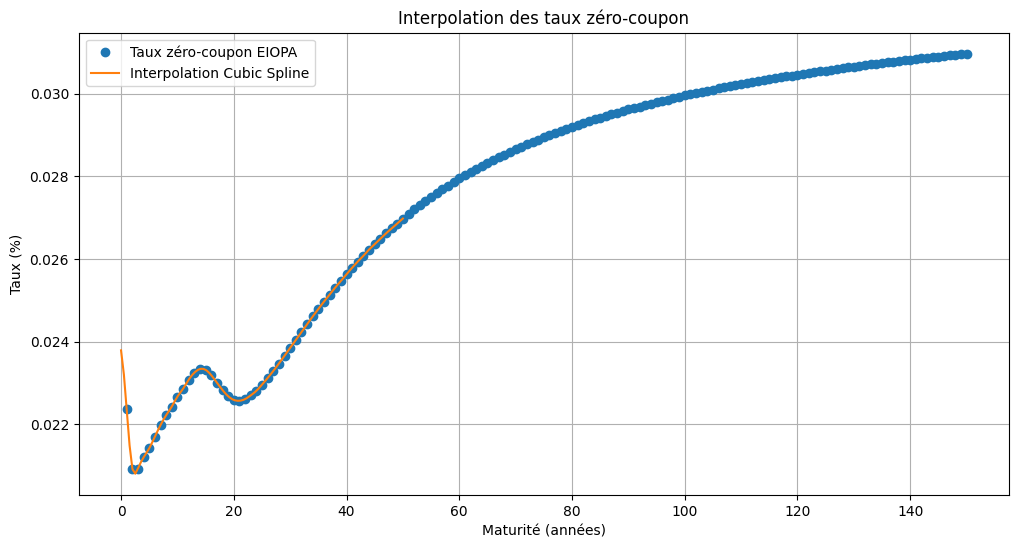

In [ ]:
from scipy.interpolate import CubicSpline

# Interpolation des taux zéro-coupon
interpolateur_zero_coupon = CubicSpline(maturities, zero_coupon_rates, bc_type='natural')

# Calcul des taux zéro-coupon interpolés
maturities_interpol = np.linspace(0, 50, 100)
zero_coupon_rates_interpol = interpolateur_zero_coupon(maturities_interpol)

# Affichage des résultats
plt.figure(figsize=(12, 6))
plt.plot(maturities, zero_coupon_rates, 'o', label='Taux zéro-coupon EIOPA')
plt.plot(maturities_interpol, zero_coupon_rates_interpol, label='Interpolation Cubic Spline')
plt.xlabel('Maturité (années)')
plt.ylabel('Taux (%)')
plt.legend()
plt.title('Interpolation des taux zéro-coupon')
plt.grid()


# Calcul du Taux Forward Instantané \( f(0,T) \) à partir de la Courbe Interpolée

Lorsque l'on dispose d'une **courbe interpolée des taux zéro-coupon** $ r(0,T) $, le **taux forward instantané** est donné par :

$$
f(0,T) = r(0,T) + T \frac{d r(0,T)}{dT}
$$

où :
- $ r(0,T) $ est le taux zéro-coupon interpolé à maturité $ T $.
- $ \frac{d r(0,T)}{dT} $ est la dérivée du taux zéro-coupon par rapport à $ T $, calculée numériquement.



In [149]:
def calculate_forward_rates(maturities, zero_coupon_rates, dr_dt_values):
    """
    Calcule les taux forward instantanés f(0,T) pour les maturités données.

    Arguments :
    maturities : np.array : Maturités en années
    zero_coupon_rates_interpol : np.array : Taux zéro-coupon interpolés
    dr_dt_values : np.array : Dérivées des taux zéro-coupon interpolés

    Retourne :
    forward_rates : np.array : Taux forward instantanés f(0,T)
    """
    forward_rates = zero_coupon_rates + maturities * dr_dt_values
    return forward_rates

# Calcul des dérivées des taux zéro-coupon interpolés
dr_dt = interpolateur_zero_coupon.derivative()
dr_dt_values = dr_dt(t_grid[1:])
zero_coupon_rates_interpol = interpolateur_zero_coupon(t_grid[1:])
# Calcul des taux forward pour les maturités données
forward_rates = calculate_forward_rates(t_grid[1:], zero_coupon_rates_interpol, dr_dt_values)

# Affichage des résultats
df_forward_rates = pd.DataFrame({'Maturité': t_grid[1:], 'Taux Forward f(0,T)': forward_rates})
print(df_forward_rates)

     Maturité  Taux Forward f(0,T)
0        0.01             0.023776
1        0.02             0.023761
2        0.03             0.023745
3        0.04             0.023728
4        0.05             0.023712
..        ...                  ...
995      9.96             0.024844
996      9.97             0.024837
997      9.98             0.024830
998      9.99             0.024823
999     10.00             0.024815

[1000 rows x 2 columns]


Calcul de la partie déterministe avec la formule :  
$$
\theta(t) = \frac{\partial f(0,t)}{\partial t} + a f(0,t) + b f(0,t) 
- \frac{\sigma^2}{2a} (1 - e^{-2at}) 
- \frac{\eta^2}{2b} (1 - e^{-2bt}) 
- \frac{\rho \sigma \eta}{a+b} (1 - e^{-(a+b)t})
$$


In [151]:
# Interpolation des taux forward
interpolateur_forward = CubicSpline(t_grid[1:], forward_rates, bc_type='natural')

# Calcul des dérivées des taux forward interpolés
dr_dt_forward = interpolateur_forward.derivative()
dr_dt_forward_values = dr_dt_forward(t_grid[1:])


In [160]:
theta = [r0]
for t in range (len(t_grid[1:])):
    
    taux_forward = forward_rates[t]
    df_dt = dr_dt_forward_values[t]

    # Calcul des termes correctifs
    terme1 = - (sigma**2 / (2 * a)) * (1 - np.exp(-2 * a * t))
    terme2 = - (eta**2 / (2 * b)) * (1 - np.exp(-2 * b * t))
    terme3 = - (rho * sigma * eta / (a + b)) * (1 - np.exp(-(a + b) * t))

    # Calcul de θ(t)
    theta_t = df_dt + a * taux_forward + b * taux_forward + terme1 + terme2 + terme3

    theta.append(theta_t)
print(len(theta),x,y)

1001 [0 1 2 3 4] [1 2 0 2 3]


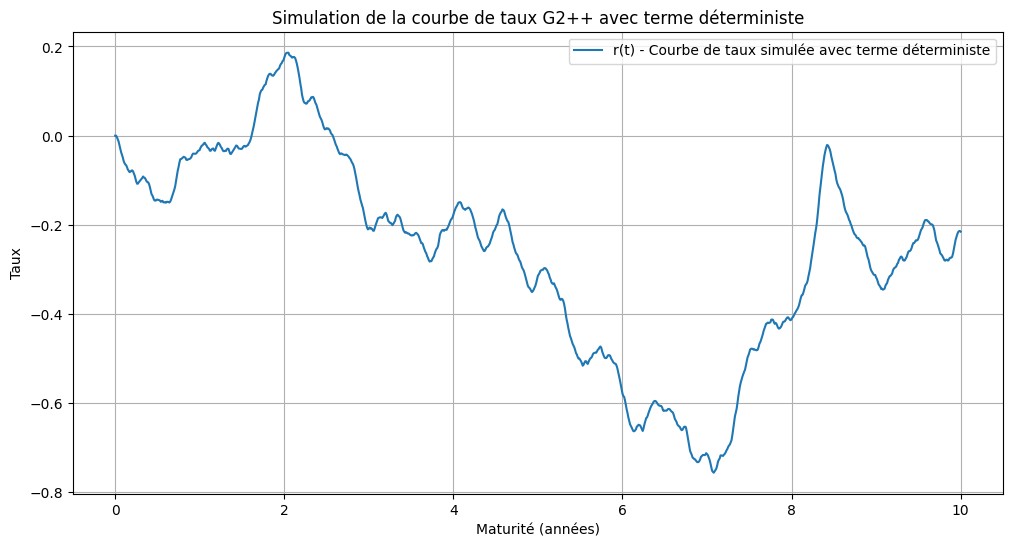

In [167]:
r_2 = x + y + theta
plt.figure(figsize=(12, 6))
plt.plot(t_grid, r_2, label='r(t) - Courbe de taux simulée avec terme déterministe')
plt.xlabel('Maturité (années)')
plt.ylabel('Taux')
plt.legend()
plt.title('Simulation de la courbe de taux G2++ avec terme déterministe')
plt.grid()
plt.show()

# Pricing d'une Obligation Zéro-Coupon \( P(t, T) \) sous le Modèle G2++

## 1. Formule de $ P(t, T) $ sous G2++

Le prix d’une obligation zéro-coupon sous G2++ est donné par :

$$
P(t, T) = e^{-A(t,T) - B(t,T) r_t}
$$

où :
- $ A(t,T) $ et $ B(t,T) $ sont des fonctions explicites dépendant des paramètres du modèle.
- $ r_t $ est le **taux court** à l'instant $ t $.

---

## 2. Expressions de $ A(t,T) $ et $ B(t,T) $

$$
B(t,T) = \frac{1 - e^{-a (T-t)}}{a}
$$

$$
A(t,T) = B(t,T) r_t - \frac{1}{2} \left( V_x(T-t) + V_y(T-t) + 2 \rho V_{xy}(T-t) \right)
$$

avec les variances et covariances :

$
V_x(T-t) = \frac{\sigma^2}{2a^3} \left( 1 - e^{-2a (T-t)} + 2a (T-t) e^{-a (T-t)} \right)
$

$
V_y(T-t) = \frac{\eta^2}{2b^3} \left( 1 - e^{-2b (T-t)} + 2b (T-t) e^{-b (T-t)} \right)
$

$
V_{xy}(T-t) = \frac{\sigma \eta \rho}{a b (a + b)} \left( 1 - e^{-(a+b) (T-t)} \right)
$



In [ ]:
# Fonctions de calcul des facteurs de B(t, T, z)
def B(t, T, a):
    return (1 - np.exp(-a * (T - t))) / a


# Fonctions de calcul des variances et covariances
def var_x(t, a, sigma):
    return (sigma**2 / (2 * a**3)) * (1 - np.exp(-2 * a * t) + 2 * a * t * np.exp(-a * t))

def var_y(t, b, eta):
    return (eta**2 / (2 * b**3)) * (1 - np.exp(-2 * b * t) + 2 * b * t * np.exp(-b * t))

def cov_xy(t, a, b, sigma, eta, rho):
    return (sigma * eta * rho / (a * b * (a + b))) * (1 - np.exp(-(a + b) * t))



# Fonction de calcul des facteurs A(t, T, a, b, sigma, eta, rho)
def A(t, T, a, b, sigma, eta, rho, r):
    B_tT = B(t, T, a)
    V_x = var_x(T - t, a, sigma)
    V_y = var_y(T - t, b, eta)
    V_xy = cov_xy(T - t, a, b, sigma, eta, rho)
    r_t = r[t]


    A_tT = B_tT * r_t - 0.5 * (V_x + V_y + 2 * rho * V_xy)
    
    return A_tT

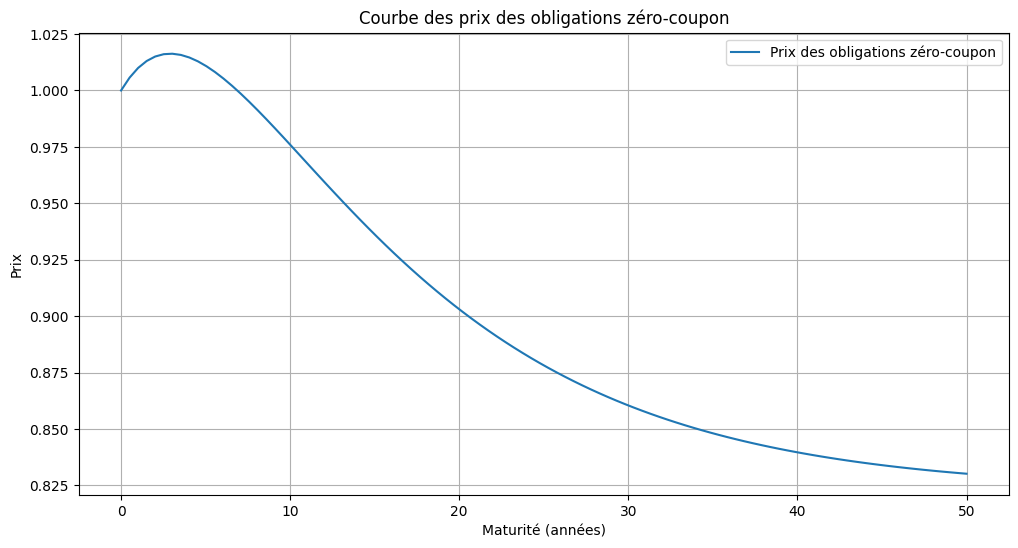

In [170]:
def prix_zero_coupon(t, T, a, b, sigma, eta, rho, r):
    A_tT = A(t, T, a, b, sigma, eta, rho)
    B_tT = B(t, T, a)
    r_t = r[t]
    
    return np.exp(-A_tT - B_tT * r_t)

# Calcul des prix des obligations zéro-coupon pour chaque maturité interpolée
zero_coupon_prices = [prix_zero_coupon(0, T, a, b, sigma, eta, rho, r) for T in maturities_interpol]

# Affichage des résultats
plt.figure(figsize=(12, 6))
plt.plot(maturities_interpol, zero_coupon_prices, label='Prix des obligations zéro-coupon')
plt.xlabel('Maturité (années)')
plt.ylabel('Prix')
plt.legend()
plt.title('Courbe des prix des obligations zéro-coupon')
plt.grid()
plt.show()

On peut maintenant calculer les taux forward définis par :
$$
f(t,T) = -\frac{\partial \ln(P(t,T))}{\partial T}
$$  
Soit : $ f(t,T) = f(0,T) + \frac{\partial A(t,T)}{\partial T} + \frac{\partial B(t,T)}{\partial T}r_t $

In [ ]:
# Fonction dérivée de B(t, T)
def dB_dT(T, t, a):
    return np.exp(-a * (T - t))

# Fonction dérivée de A(t, T)
def dA_dT(T, t, a, b, sigma, eta, rho):
    dVx_dT = (sigma**2 / (2 * a**2)) * (np.exp(-2 * a * (T - t)) - np.exp(-a * (T - t)))
    dVy_dT = (eta**2 / (2 * b**2)) * (np.exp(-2 * b * (T - t)) - np.exp(-b * (T - t)))
    dVxy_dT = (sigma * eta * rho / (a * b)) * np.exp(- (a + b) * (T - t))
    return -0.5 * (dVx_dT + dVy_dT + 2 * dVxy_dT)

# Fonction de taux forward f(t,T) sous G2++
def forward_rate_G2pp(t, T, a, b, sigma, eta, rho, r, f_0_T):
    dA = dA_dT(T, t, a, b, sigma, eta, rho)
    dB = dB_dT(T, t, a)
    r_t = r[t]
    return f_0_T + dA + dB * r_t

# Exemple : calcul du taux forward pour T=5 ans
t = 2  # Instant présent
T = 5  # Maturité en années
f_0_T = forward_rates[T]  # Taux forward initial observé

forward_rates_t_T = [forward_rate_G2pp(t, T, a, b, sigma, eta, rho, r, f_0_T) for t in range(1,N+1)]


Taux forward sous G2++ pour f(2,5) : 0.0280


3) Pricing de Cap

Quelle formule de pricing on utilise ?

#### 1. Formule de marché pour Pricer un Cap

Un **cap** peut être décomposé en une série de **caplets**, chacun correspondant à une option sur taux d'intérêt forward. La formule de Black est utilisée pour pricer chaque caplet :

$
Cpl(t, T_i, T_{i+1}, \tau_i, N, K) = N P(t, T_{i+1}) \tau_i \left( F(t, T_i, T_{i+1}) \Phi(d_1) - K \Phi(d_2) \right)
$

où :
- $P(t, T_{i+1})$ est le prix du zéro-coupon à l'instant $t$ pour l'échéance $T_{i+1}$,
- $F(t, T_i, T_{i+1})$ est le taux forward entre $T_i$ et $T_{i+1}$,
- $N$ est le nominal,
- $\tau_i$ est la fraction de l'année entre $T_i$ et $T_{i+1}$,
- $K$ est le taux d'exercice du cap,
- $\Phi$ est la fonction de répartition de la loi normale,
- $d_1$ et $d_2$ sont donnés par :

$
d_1 = \frac{\ln \left( \frac{F(t, T_i, T_{i+1})}{K} \right) + \frac{1}{2} \sigma^2 (T_{i+1} - t)}{\sigma \sqrt{T_{i+1} - t}}
$

$
d_2 = d_1 - \sigma \sqrt{T_{i+1} - t}
$

où $\sigma$ est la **volatilité implicite** du caplet.

Le prix total d’un cap est obtenu en sommant les prix des caplets :

$
C(t) = \sum_{i=1}^{n} Cpl(t, T_i, T_{i+1}, \tau_i, N, K)
$

---

#### 2. Formule théorique de pricing du Cap sous G2++

Dans un cadre plus théorique, notamment sous un modèle comme **G2++**, le prix d’un **cap** est obtenu en intégrant les paramètres du modèle pour estimer la volatilité effective du taux forward. Il est donné par la même formule :

$
Cap^{\text{Black}}(0, \mathcal{T}, \tau, N, K, \sigma_{a,b}) =
N \sum_{i=a+1}^{b} P(0, T_i) \tau_i \text{Bl}(K, F(0, T_{i-1}, T_i), v_i),
$

où **$ v_i $** la volatilité effective du taux forward est définie par :

- $
v_i = \sigma_{a,b} \sqrt{T_{i-1}}.
$  
où $ \sigma_{a,b} $ est la volatilité globale du cap, estimée à partir des paramètres du modèle par :  
$
\sigma_{a,b}^2 = \frac{1}{T} \int_0^T \left[ V_x(s) + V_y(s) + 2 \rho V_{xy}(s) \right] ds
$

$
\sigma_{a,b} = \sqrt{\frac{1}{T} \int_0^T \left[ V_x(s) + V_y(s) + 2 \rho V_{xy}(s) \right] ds}
$


##### **Formule de Black pour un Caplet sous G2++**
Chaque caplet est valué selon la **formule de Black**, où la volatilité effective $ v_i $ est issue du modèle :

$
\text{Bl}(K, F, v) = F \Phi(d_1) - K \Phi(d_2),
$

avec :

$
d_1(K, F, v) = \frac{\ln(F/K) + v^2/2}{v},
$

$
d_2(K, F, v) = \frac{\ln(F/K) - v^2/2}{v} = d_1 - v_i = d_1 - \sigma_{a, b}\sqrt{T_{i-1}}.
$

📖 **Référence** : Brigo D., Mercurio F., *Interest Rate Models - Theory and Practice*.


In [122]:
from scipy.stats import norm
from scipy.integrate import quad

def sigma_alpha_beta(t, T, a, b, sigma, eta, rho):
    def integrand(s, a, b, sigma, eta, rho):
        V_x = var_x(s, a, sigma)
        V_y = var_y(s, b, eta)
        V_xy = cov_xy(s, a, b, sigma, eta, rho)
        return V_x + V_y + 2 * rho * V_xy

    integral_value, _ = quad(integrand, 0, T, args=(a, b, sigma, eta, rho))
    return np.sqrt(integral_value / T)

def theoric_black_cap_price(T, tau, N, K, sigma_a_b, P, F):
    """
    Calcule le prix d'un cap selon la formule de Black sous le modèle G2++.

    Arguments :
    T : array : Maturités des caplets
    tau : array : Fractions de l'année entre les maturités
    N : float : Nominal
    K : float : Taux d'exercice du cap
    sigma_a_b : float : Volatilité globale du cap
    P : array : Prix des obligations zéro-coupon pour chaque maturité
    F : array : Taux forward pour chaque caplet

    Retourne :
    Prix du cap
    """
    cap_price = 0.0
    for i in range(1, len(T)):
        v_i = sigma_a_b * np.sqrt(T[i-1])
        d1 = (np.log(F[i-1] / K) + 0.5 * v_i**2) / v_i
        d2 = d1 - v_i
        caplet_price = N * P[i] * tau[i] * (F[i-1] * norm.cdf(d1) - K * norm.cdf(d2))
        cap_price += caplet_price

    return cap_price

# Exemple d'utilisation
T = np.array([1, 2, 3, 4, 5])  # Maturités des caplets
tau = np.array([0.5, 0.5, 0.5, 0.5, 0.5])  # Fractions de l'année entre les maturités
N = 1000000  # Nominal
K = 0.03  # Taux d'exercice du cap
sigma_a_b = 0.02  # Volatilité globale du cap
P = np.array([0.98, 0.95, 0.92, 0.89, 0.86])  # Prix des obligations zéro-coupon
F = np.array([0.025, 0.027, 0.029, 0.031, 0.033])  # Taux forward

cap_price = theoric_black_cap_price(T, tau, N, K, sigma_a_b, P, F)
print(f"Prix du cap : {cap_price}")


Prix du cap : 530.3325704294633


4) Calibrage du modèle

Les algorithmes pouvant être utilisés pour l'optimisation de nos paramètres sont : 
- l'algorithme de **Nelder-Mead**, dépendant cependant fortement du point d'origine car s'arrêtant au premier minimum local
- l'algorithme de **Marquardt-Levenberg** qui trouve bien le minimum global mais qui, forcément, est bien plus long

## II - Modèle de Black-Scholes

1) Simulation

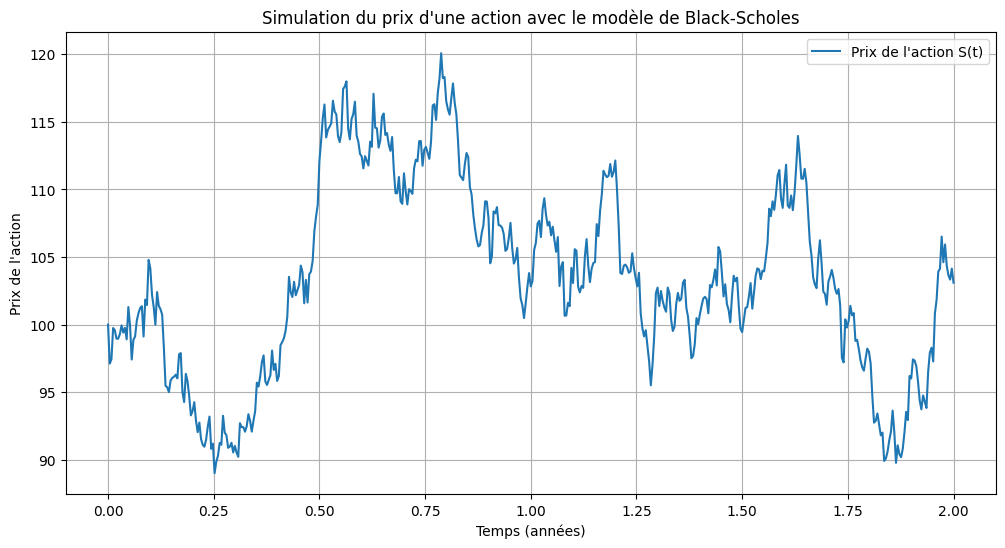

In [81]:
# Fonction de simulation du prix d'une action avec le modèle de Black-Scholes
def simulate_black_scholes(S0, mu, sigma, T, N):
    """
    Simule le prix d'une action selon le modèle de Black-Scholes.

    Arguments :
    S0 : float : Prix initial de l'action
    mu : float : Taux de rendement moyen
    sigma : float : Volatilité de l'action
    T : float : Horizon de temps (années)
    N : int : Nombre de pas de temps

    Retourne :
    t_grid : np.array : Grille temporelle
    S : np.array : Série des prix simulés
    """
    dt = T / N  # Pas de temps
    t_grid = np.linspace(0, T, N + 1)  # Grille de temps

    # Génération du mouvement brownien
    dW = np.random.normal(0, np.sqrt(dt), N)
    W = np.concatenate(([0], np.cumsum(dW)))

    # Simulation du prix de l'action
    S = np.zeros(N + 1)
    S[0] = S0
    for i in range(1, N + 1):
        S[i] = S[i - 1] * np.exp((mu - 0.5 * sigma**2) * dt + sigma * dW[i - 1])

    return t_grid, S

# Paramètres du modèle
S0 = 100  # Prix initial de l'action
mu = 0.05  # Taux de rendement moyen
sigma_BS = 0.2  # Volatilité de l'action
T_BS = 2  # Horizon de simulation en années
N_BS = 500  # Nombre de pas de temps

# Simulation du pricing avec Black-Scholes
t_grid_BS, S_BS = simulate_black_scholes(S0, mu, sigma_BS, T_BS, N_BS)

# Affichage du prix simulé
plt.figure(figsize=(12, 6))
plt.plot(t_grid_BS, S_BS, label="Prix de l'action S(t)")
plt.xlabel("Temps (années)")
plt.ylabel("Prix de l'action")
plt.legend()
plt.title("Simulation du prix d'une action avec le modèle de Black-Scholes")
plt.grid()
plt.show()

# Stockage des résultats
df_black_scholes = pd.DataFrame({'Temps': t_grid_BS, 'Prix de l\'action S(t)': S_BS})

2) Calibrage sur nos données

In [ ]:
from scipy.optimize import minimize

# Fonction d'objectif pour la calibration de la volatilité implicite dans le modèle de Black-Scholes
def black_scholes_price(S, K, T, r, sigma):
    """
    Calcule le prix d'une option d'achat européenne avec le modèle de Black-Scholes.

    Arguments :
    S : float : Prix du sous-jacent
    K : float : Prix d'exercice de l'option
    T : float : Temps jusqu'à l'échéance (en années)
    r : float : Taux sans risque
    sigma : float : Volatilité implicite

    Retourne :
    Prix théorique de l'option d'achat
    """
    from scipy.stats import norm

    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

def implied_volatility_objective(sigma, S, K, T, r, market_price):
    """
    Fonction d'erreur pour trouver la volatilité implicite en minimisant l'écart
    entre le prix théorique et le prix observé sur le marché.

    Arguments :
    sigma : float : Volatilité testée
    S, K, T, r : paramètres du modèle de Black-Scholes
    market_price : float : Prix observé de l'option

    Retourne :
    Erreur quadratique entre le prix observé et le prix théorique
    """
    return (black_scholes_price(S, K, T, r, sigma) - market_price) ** 2


In [82]:
df_options = pd.read_excel(data, sheet_name="Call Euro Stoxx 50")
df_options

,Strike,Price,Expiry Date,Volume
0,4325,65.2,2023-12-15,32
1,4350,50.3,2023-12-15,1623
2,4375,37.7,2023-12-15,2002
3,4375,76.9,2024-01-19,52
4,4375,103.9,2024-02-16,2020
5,4325,161.4,2024-03-15,22
6,4350,146.1,2024-03-15,61
7,4375,131.1,2024-03-15,250
8,4325,182.8,2024-06-21,2080
9,4400,204.2,2024-09-20,1175


In [83]:

# Sélection des données pertinentes
S_market = df_options["Price"].values[0]  # Prix du sous-jacent
K_values = df_options["Strike"].values  # Prix d'exercice
T_values = df_options["Maturity"].values  # Temps jusqu'à maturité (en années)
market_prices = df_options["Market Price"].values  # Prix de marché des options
r = 0.02  # Hypothèse de taux sans risque à 2%

# Estimation de la volatilité implicite pour chaque option
implied_vols = []
for i in range(len(K_values)):
    result = minimize(implied_volatility_objective, x0=0.2, args=(S_market, K_values[i], T_values[i], r, market_prices[i]), 
                      method="Nelder-Mead", bounds=[(0.01, 1.0)])
    implied_vols.append(result.x[0])

# Stockage des résultats
df_calibrated_vols = pd.DataFrame({
    "Strike": K_values,
    "Maturity": T_values,
    "Market Price": market_prices,
    "Volatilité Implicite": implied_vols
})


KeyError: 'Spot Price'